# 1D and 2D diffusion equations
Solution of the 1D and 2D diffusion equation using:
1. Explicit method
2. Implicit method
    - ~~Thomas Algorithm~~ (Will not be covered)
    - Iterative methods (Jacobi, Gauss-Seidel)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1D Diffusion Equation
$$ \frac{\partial c}{\partial t} = D \frac{\partial^2 c}{\partial x^2} $$


## Comparing explicit FTCS vectorized and non vectorized (python loop) code performance

In [ ]:
import time
def initialize_Dirichlet(c):
    c[0] = 1.0
    c[-1] = 0.0
    return
def apply_BC_Dirichlet(c):
    # Dirichlet (fixed) boundary condition
    c[0] = 1.0
    c[-1] = 0.0
    return

N_x = 10
timesteps = 1000
dx = 1.0
dt = 0.2
Diffusivity = 1.0
x_array = np.arange(0, N_x * dx, dx)

# Initialize concentration profiles
c_exp_loop = np.zeros(N_x)
c_exp_vec = np.zeros(N_x)
# Initialize / Apply BC @ t=0
initialize_Dirichlet(c_exp_loop)
initialize_Dirichlet(c_exp_vec)

c_next_loop = np.copy(c_exp_loop)
c_next_vec = np.copy(c_exp_vec)

# ---------------------------------------------------------
# 1. Explicit FTCS with Python loop
# ---------------------------------------------------------

start_time = time.perf_counter()
for t in range(timesteps):
    for i in range(1, N_x - 1):
        dc_dt = Diffusivity * (c_exp_loop[i - 1] - 2 * c_exp_loop[i] + c_exp_loop[i + 1]) / (dx ** 2)
        c_next_loop[i] = c_exp_loop[i] + dc_dt * dt
    apply_BC_Dirichlet(c_next_loop)
    c_exp_loop = np.copy(c_next_loop)
end_time = time.perf_counter()

loop_time = end_time - start_time
print(f"Loop-based Explicit FTCS execution time: {loop_time:.5f} seconds")

# ---------------------------------------------------------
# 2. Explicit FTCS with Vectorization
# ---------------------------------------------------------
start_time = time.perf_counter()
for t in range(timesteps):
    # Vectorized update for interior nodes [1:-1]
    c_next_vec[1:-1] = c_exp_vec[1:-1] + Diffusivity * dt / (dx ** 2) * (
        # 

In [ ]:
................ANSWER HERE ...........

In [ ]:
.........................)
    apply_BC_Dirichlet(c_next_vec)
    c_exp_vec = np.copy(c_next_vec)
end_time = time.perf_counter()

vec_time = end_time - start_time
print(f"Vectorized Explicit FTCS execution time: {vec_time:.5f} seconds")

# Speedup
speedup = loop_time / vec_time if vec_time > 0 else 0
print(f"\nVectorized code is {speedup:.2f}x faster than the loop implementation.")

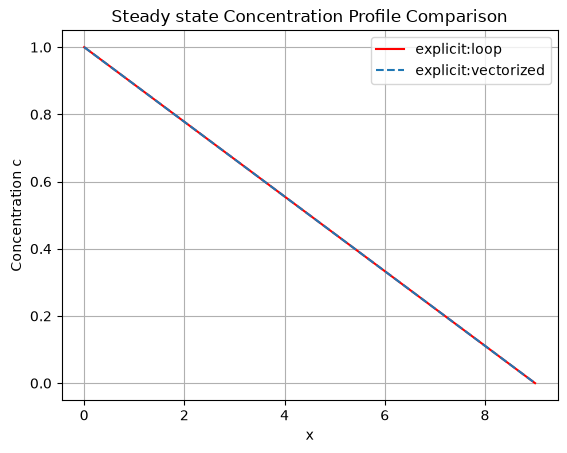

In [4]:
# Steady stae Concentration Profiles
plt.plot(x_array, c_exp_loop, 'r-', label='explicit:loop')
plt.plot(x_array, c_exp_vec, '--', label='explicit:vectorized')
plt.xlabel('x')
plt.ylabel('Concentration c')
plt.title('Steady state Concentration Profile Comparison')
plt.legend()
plt.grid(True)
plt.show()

### Answer here: Which method is faster and why?


## Comparing FTCS, BTCS using iterative solvers

In [6]:
# 1. Simulation Setup
N_x = 20                 # Number of spatial grid points
timesteps = 1000         # Number of time steps to run
dx = 1.0                 # Grid spacing
dt = 0.2                 # Time step
Diffusivity = 1.0        # Diffusion coefficient
tol = 1e-6               # Convergence tolerance for iterative solvers
max_iters = 50         # Maximum iteration limit per time step

x_array = np.arange(0, N_x * dx, dx)
alpha = Diffusivity * dt / (dx**2)

# ---------------------------------------------------------
# Boundary Conditions
def initialize_Dirichlet(c):
    c[0] = 1.0
    c[-1] = 0.0
    return
def apply_BC_Dirichlet(c):
    # Dirichlet (fixed) boundary condition
    c[0] = 1.0
    c[-1] = 0.0
    return

In [9]:
# ---------------------------------------------------------
# 2. Solver Implementations
# --- A. Explicit FTCS ---
c_exp = np.zeros(N_x)
c_exp_new = np.zeros(N_x)
initialize_Dirichlet(c_exp)
apply_BC_Dirichlet(c_exp)

for t in range(timesteps):
    for i in range(1, N_x - 1):
        dc_dt = Diffusivity * (c_exp[i - 1] - 2 * c_exp[i] + c_exp[i + 1]) / (dx**2)
        c_exp_new[i] = c_exp[i] + dc_dt * dt
    apply_BC_Dirichlet(c_exp_new)
    c_exp = np.copy(c_exp_new)


# --- B. Implicit Jacobi ---
c_jac = np.zeros(N_x)
c_jac_new = np.zeros(N_x)
initialize_Dirichlet(c_jac)
apply_BC_Dirichlet(c_jac)

A = np.zeros(N_x)
B = np.zeros(N_x)
C = np.zeros(N_x)
D = np.zeros(N_x)

jac_iterations = []

for t in range(timesteps):
    A[1:N_x - 1] = -alpha
    B[1:N_x - 1] = 1 + 2 * alpha
    C[1:N_x - 1] = -alpha
    D[1:N_x - 1] = c_jac[1:N_x - 1]
    
    iters = 0
    c_jac_new = np.copy(c_jac)
    
    for iteration in range(max_iters):
        iters += 1
        c_old_iter = np.copy(c_jac_new)
        
        for i in range(1, N_x - 1):
            c_jac_new[i] = (D[i] - A[i] * c_jac[i - 1] - C[i] * c_jac[i + 1]) / B[i]
        
        # vectorized form
        c_jac_new[1:-1] = (D[1:-1] - A[1:-1] * c_jac[:-2] - C[1:-1] * c_jac[2:]) / B[1:-1]
        apply_BC(c_jac_new)
        
        # Check convergence
        if np.max(np.abs(c_jac_new - c_old_iter)) < tol:
            break
        c_jac = np.copy(c_jac_new)
        
    c_jac = np.copy(c_jac_new)
    jac_iterations.append(iters)


# --- C. Implicit Red-Black Gauss-Seidel ---
c_rb = np.zeros(N_x)
initialize_Dirichlet(c_rb)
apply_BC(c_rb)

rb_iterations = []

for t in range(timesteps):
    A[1:N_x - 1] = -alpha
    B[1:N_x - 1] = 1 + 2 * alpha
    C[1:N_x - 1] = -alpha
    D[1:N_x - 1] = c_rb[1:N_x - 1]
    
    iters = 0
    
    for iteration in range(max_iters):
        iters += 1
        c_old_iter = np.copy(c_rb)
        
        # Red points (Even indices)
        for i in range(1, N_x - 1):
            # ----------- ANSWER HERE -----------

        
        # Black points (Odd indices)
        for i in range(1, N_x - 1):
            # ----------- ANSWER HERE -----------

        
        # Check convergence
        if np.max(np.abs(c_rb - c_old_iter)) < tol:
            break
            
    rb_iterations.append(iters)

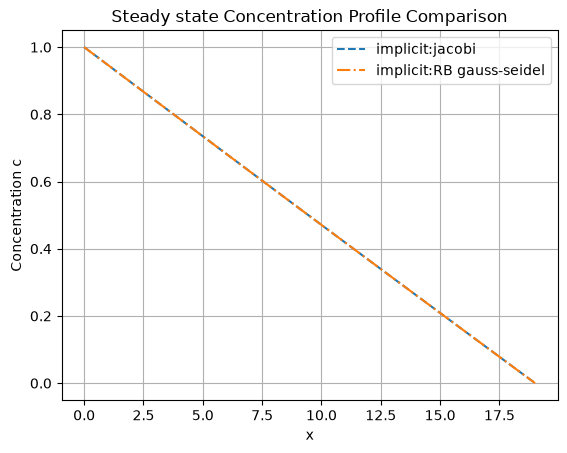

In [10]:
# Steady stae Concentration Profiles
# plt.plot(x_array, c_exp, 'r-', label='explicit')
plt.plot(x_array, c_jac, '--', label='implicit:jacobi')
plt.plot(x_array, c_rb, '-.', label='implicit:RB gauss-seidel')
plt.xlabel('x')
plt.ylabel('Concentration c')
plt.title('Steady state Concentration Profile Comparison')
plt.legend()
plt.grid(True)
plt.show()

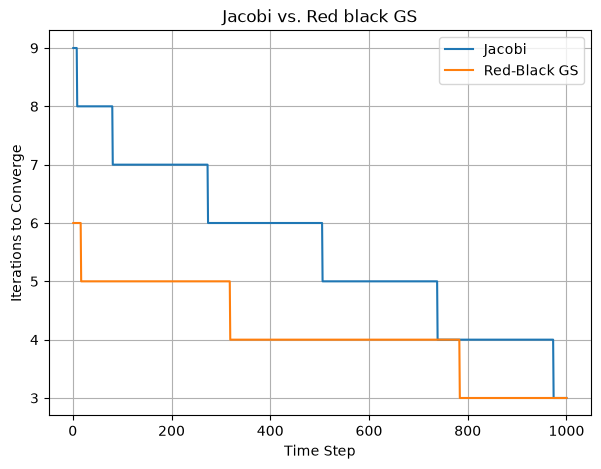

In [11]:
# Convergence Iterations per Time Step
plt.figure(figsize=(7, 5))
plt.plot(range(1, timesteps + 1), jac_iterations, label='Jacobi')
plt.plot(range(1, timesteps + 1), rb_iterations, label='Red-Black GS')
plt.xlabel('Time Step')
plt.ylabel('Iterations to Converge')
plt.title('Jacobi vs. Red black GS')
plt.legend()
plt.grid(True)
plt.show()

# 2D diffusion equation

$$\frac{\partial c}{\partial t} = D \left( \frac{\partial^2 c}{\partial x^2} + \frac{\partial^2 c}{\partial y^2} \right) = D\nabla^2 c $$

## Explicit method

$$\frac{c_{i,j}^{t+1} - c_{i,j}^t}{\Delta t} = D \left[ \frac{c_{i+1,j}^{t} + c_{i-1,j}^{t} + c_{i,j+1}^{t} + c_{i,j-1}^{t} - 4c_{i,j}^{t} }{\Delta x^2} \right]$$

$$c_{i,j}^{t+1} = c_{i,j}^t + \alpha \left( c_{i+1,j}^t + c_{i-1,j}^t + c_{i,j+1}^t + c_{i,j-1}^t - 4c_{i,j}^t \right)$$
i.e. dc/dt = add all 4 neighbour c's - 4 times the central point c


## Implicit method
$t+1$:
$$\frac{c_{i,j}^{t+1} - c_{i,j}^t}{\Delta t} = D \left[ \frac{c_{i+1,j}^{t+1} + c_{i-1,j}^{t+1} + c_{i,j+1}^{t+1} + c_{i,j-1}^{t+1} - 4c_{i,j}^{t+1} }{\Delta x^2} \right]$$

$$ -\alpha c_{i-1, j}^{t+1} -\alpha c_{i, j-1}^{t+1} + (1 + 4\alpha )c_{i, j}^{t+1} -\alpha c_{i+1, j}^{t+1} -\alpha c_{i, j+1}^{t+1} = c_{i, j}^t $$
In general terms of coefficients,
$$ A_{xi} c_{i-1, j}^{t+1} + A_{yi} c_{i, j-1}^{t+1} + B_{i, j} c_{i, j}^{t+1} + C_{xi} c_{i+1, j}^{t+1} + C_{yi} c_{i, j+1}^{t+1} = D_{i, j} $$

### Stability Constraint:

Unlike the 1D case where $\alpha \le 0.5$, the 2D explicit method is more restrictive. For stability, it must satisfy:$$\alpha \le 0.25 \quad \text{or} \quad \Delta t \le \frac{\Delta x^2}{4D}$$

In [16]:
from matplotlib import cm # for choosing colormap for 3D plot

In [215]:
N_x, N_y = 20, 20
timesteps = 40
dx = 1.0 #  dx = dy
dt = 0.3
Diffusivity = 1.0
alpha = Diffusivity*dt/(dx**2)

In [216]:
def initialize_centre(c):
    c[N_x//2, N_y//2] = 1.0
    return
def apply_BC(c):
#    # Dirichlet (fixed) boundary condition
    # Y boundary
    # c[0, :] = 1.0
    # c[N_x-1, :] = 0.0
    # X boundary
    # c[:, 0] = 1.0
    # c[:, N_y-1] = 0.0
#    # Neumann (zero-flux) boundary condition
    # Y boundary
    c[0, :] = c[1, :]
    c[N_x-1, :] = c[N_x-2, :]
    # X boundary
    c[:, 0] = c[:, 1]
    c[:, N_y-1] = c[:, N_y-2]
    return

In [217]:
# Initializing parameters
c_exp = np.zeros( (N_x, N_y) )
initialize_centre(c_exp)
apply_BC(c_exp)
c_exp_new = c_exp.copy()

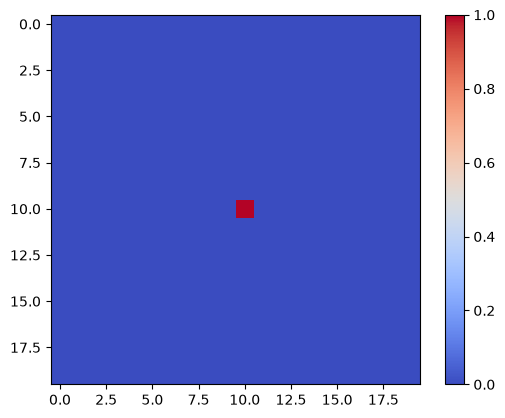

In [218]:
plt.close('all')
plt.imshow(c_exp, cmap=cm.coolwarm) # for plotting 2D projection with color as 3rd dimension
plt.colorbar()
plt.show()

In [219]:
for t in range(timesteps):
    # vectorized form
    c_exp_new[1:-1, 1:-1] = c_exp[1:-1, 1:-1] + alpha*(c_exp[0:-2, 1:-1] + c_exp[2: , 1:-1] + c_exp[1:-1, 0:-2] + c_exp[1:-1, 2: ] - 4*c_exp[1:-1, 1:-1])
                                   
    # update c_exp each iteration
    apply_BC(c_exp_new)
    c_exp = np.copy(c_exp_new)

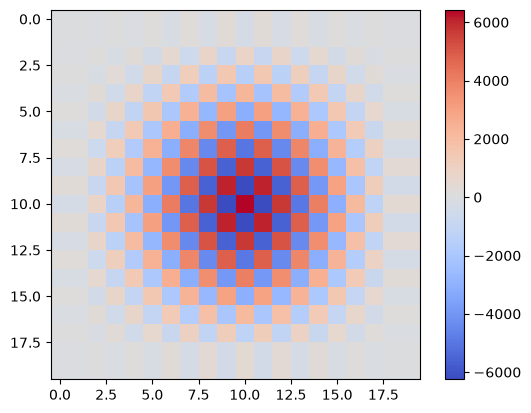

In [220]:
plt.close('all')
plt.imshow(c_exp, cmap=cm.coolwarm) # for plotting 2D projection with color as 3rd dimension
plt.colorbar()
plt.show()

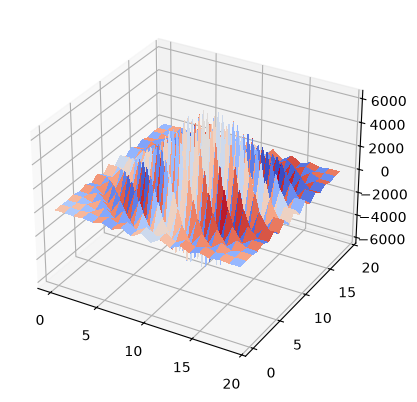

In [221]:
# %matplotlib widget
plt.close('all')
%matplotlib inline
# 3D surface plot  
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(2) # creates a different window
ax = fig.add_subplot(111, projection='3d') # adds a third axis
x_array = np.arange(0, N_x, dx)
y_array = np.arange(0, N_y, dx)
X, Y = np.meshgrid(y_array, x_array) # creates an xy grid of size N_x*N_y
surf = ax.plot_surface(X, Y, c_exp, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
# fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

### 2D Diffusion Equation: Implicit Jacobi Method
2D diffusion equation:

$$c_{i,j}^{k+1, t+1} = \frac{c_{i,j}^t + \alpha \left( c_{i-1,j}^{k, t+1} + c_{i+1,j}^{k, t+1} + c_{i,j-1}^{k, t+1} + c_{i,j+1}^{k, t+1} \right)}{1 + 4\alpha}$$

In [222]:
N_x, N_y = 20, 20
timesteps = 40
dx = 1.0 #  dx = dy
dt = 0.5
Diffusivity = 1.0
alpha = Diffusivity*dt/(dx**2)

In [223]:
def initialize_centre(c):
    c[N_x//2, N_y//2] = 1.0
    return
def apply_BC(c):
#    # Dirichlet (fixed) boundary condition
    # Y boundary
    # c[0, :] = 1.0
    # c[N_x-1, :] = 0.0
    # X boundary
    # c[:, 0] = 1.0
    # c[:, N_y-1] = 0.0
#    # Neumann (zero-flux) boundary condition
    # Y boundary
    c[0, :] = c[1, :]
    c[N_x-1, :] = c[N_x-2, :]
    # X boundary
    c[:, 0] = c[:, 1]
    c[:, N_y-1] = c[:, N_y-2]
    return

In [224]:
# Initializing parameters
c_jac = np.zeros( (N_x, N_y) )
c_jac_previous_time = np.zeros_like(c_jac)
total_iterations = 15
initialize_centre(c_jac)
apply_BC(c_jac)
c_jac_new = c_jac.copy()

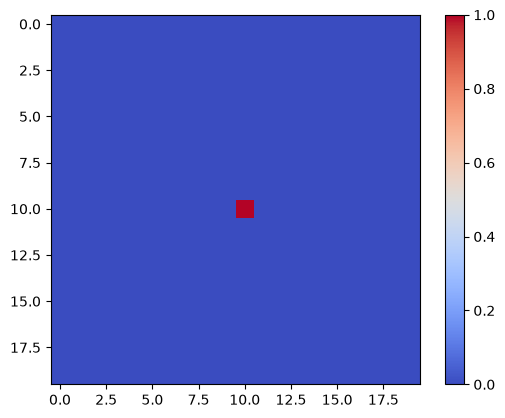

In [225]:
plt.imshow(c_jac, cmap=cm.coolwarm) # for plotting 2D projection with color as 3rd dimension
plt.colorbar()
plt.show()

In [226]:
for t in range(timesteps):
    # update coefficients after each timestep
    c_jac_previous_time[1:N_x-1, 1:N_y-1] = c_jac[1:N_x-1, 1:N_y-1] # i.e. composition at previous timestep
    
    for iterations in range(total_iterations):
        # vectorized form
        c_jac_new[1:-1, 1:-1] = (c_jac_previous_time[1:-1, 1:-1] + \
                                 alpha*(c_jac[0:-2, 1:-1] + c_jac[2: , 1:-1] + c_jac[1:-1, 0:-2] + c_jac[1:-1, 2: ])) / (1+4*alpha)
                                       
        # update c_jac each iteration
        apply_BC(c_jac_new)
        c_jac = np.copy(c_jac_new)

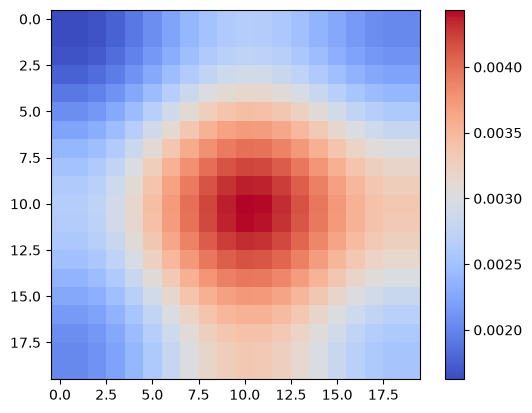

In [227]:
plt.imshow(c_jac, cmap=cm.coolwarm) # for plotting 2D projection with color as 3rd dimension
plt.colorbar()
plt.show()

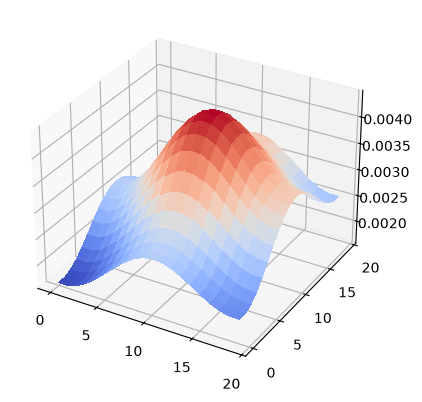

In [228]:
# %matplotlib widget
plt.close('all')
# %matplotlib inline
# 3D surface plot  
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(2) # creates a different window
ax = fig.add_subplot(111, projection='3d') # adds a third axis
x_array = np.arange(0, N_x, dx)
y_array = np.arange(0, N_y, dx)
X, Y = np.meshgrid(y_array, x_array) # creates an xy grid of size N_x*N_y
surf = ax.plot_surface(X, Y, c_jac, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
# fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

### Gauss Seidel (Red Black)

The asterisk ($*$) below denotes that we use the most recent value available.

$$c_{i,j}^{k+1} = \frac{c_{i,j}^t + \alpha (c_{i-1,j}^* + c_{i+1,j}^* + c_{i,j-1}^* + c_{i,j+1}^*)}{1 + 4\alpha}$$

In Red-Black, we ensure that the **"neighbors" are always from the opposite set**.

A grid point is Red if $(i + j)\%2 == 0$ is even, and Black if $(i + j) \%2 \neq 0 $ is odd.

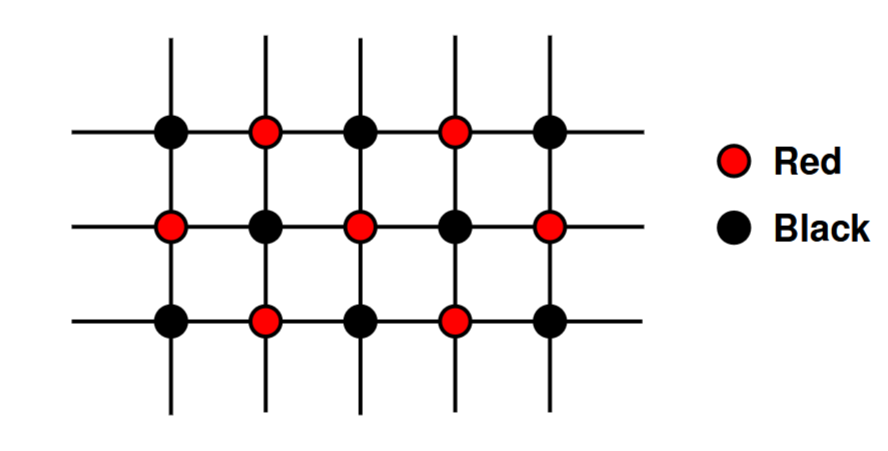

#### Step 1: Update Red Cells

Update all $(i, j)$ where $(i + j) \% 2 == 0$. Since all neighbors of a Red cell are Black, this step uses the values from the previous iteration ($k$):$$c_{Red}^{k+1} = f(c_{Black}^{k})$$

#### Step 2: Update Black Cells

Update all $(i, j)$ where $(i + j) \% 2 != 0$. Since all neighbors of a Black cell are Red, and those Red cells were just updated in Step 1, this step uses the new values ($k+1$):$$c_{Black}^{k+1} = f(c_{Red}^{k+1})$$